# Regressão 01 - tarefa 02 - transformações em X e Y

### 1. Melhorando o ajuste no percentual de gorjetas

a. Vamos partir do modelo feito na última tarefa, o que relaciona ```tip_pct``` e ```net_bill```. Carregue a base, os pacotes e reproduza este modelo aqui.

In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt 

tips = sns.load_dataset("tips")
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips['tip_pct'] = tips['tip'] / tips['net_bill']

R²: 0.0913


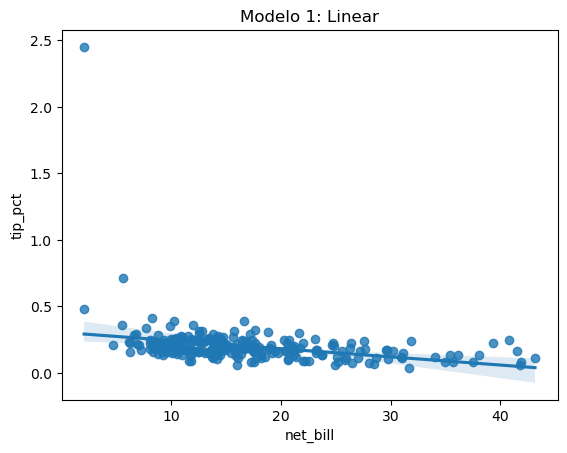

In [10]:
# Certifique-se de que as variáveis já foram criadas:
# tips['net_bill'] = tips['total_bill'] - tips['tip']
# tips['tip_pct'] = tips['tip'] / tips['net_bill']

res1 = smf.ols('tip_pct ~ net_bill', data=tips).fit()
print(f'R²: {res1.rsquared:.4f}')

sns.regplot(x='net_bill', y='tip_pct', data=tips)
plt.title('Modelo 1: Linear')
plt.show()

### 2. ajuste o modelo de ```tip_pct``` em função do logaritmo de ```net_bill```.

R²: 0.2017


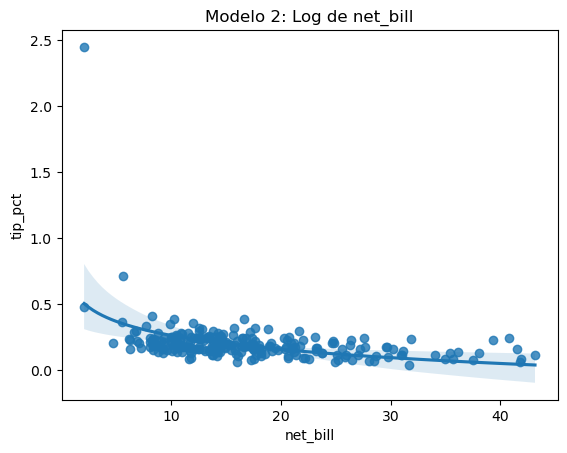

In [11]:
res2 = smf.ols('tip_pct ~ np.log(net_bill)', data=tips).fit()
print(f'R²: {res2.rsquared:.4f}')

sns.regplot(x='net_bill', y='tip_pct', data=tips, logx=True)
plt.title('Modelo 2: Log de net_bill')
plt.show()

###  3. ajuste o modelo de ```tip_pct``` em função de um polinômio de segundo grau em ```net_bill```.

R²: 0.1576


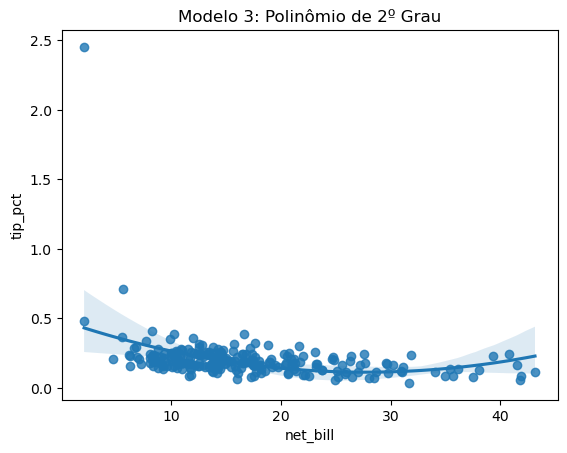

In [12]:
res3 = smf.ols('tip_pct ~ net_bill + np.power(net_bill, 2)', data=tips).fit()
print(f'R²: {res3.rsquared:.4f}')

sns.regplot(x='net_bill', y='tip_pct', data=tips, order=2)
plt.title('Modelo 3: Polinômio de 2º Grau')
plt.show()

###  4. ajuste um modelo no log do ```tip_pct``` em função de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```

R² (escala log): 0.2353
R² (escala original): 0.1144


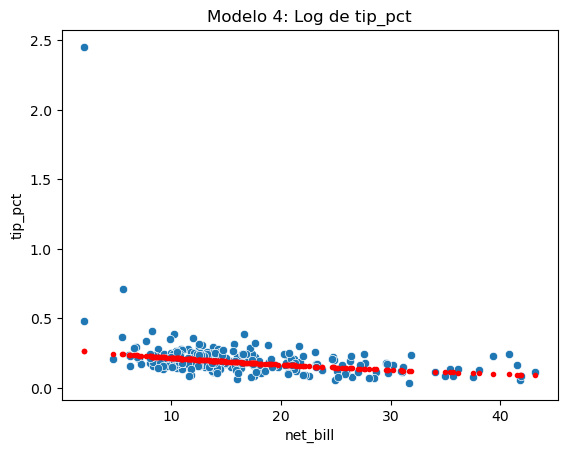

In [13]:
res4 = smf.ols('np.log(tip_pct) ~ net_bill', data=tips).fit()

# Calculando R² na escala original
tips['pred_item4'] = np.exp(res4.fittedvalues)
r2_original_4 = tips[['tip_pct', 'pred_item4']].corr().iloc[0,1]**2

print(f'R² (escala log): {res4.rsquared:.4f}')
print(f'R² (escala original): {r2_original_4:.4f}')

sns.scatterplot(x='net_bill', y='tip_pct', data=tips)
plt.plot(tips['net_bill'], tips['pred_item4'], 'r.', label='Predição')
plt.title('Modelo 4: Log de tip_pct')
plt.show()

###  5. ajuste um modelo no log do ```tip_pct``` em função do log de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```.

R² (escala log): 0.2935
R² (escala original): 0.3089


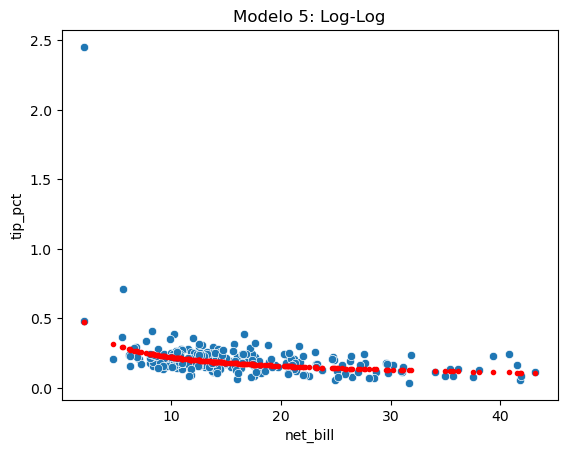

In [14]:
res5 = smf.ols('np.log(tip_pct) ~ np.log(net_bill)', data=tips).fit()

# Calculando R² na escala original
tips['pred_item5'] = np.exp(res5.fittedvalues)
r2_original_5 = tips[['tip_pct', 'pred_item5']].corr().iloc[0,1]**2

print(f'R² (escala log): {res5.rsquared:.4f}')
print(f'R² (escala original): {r2_original_5:.4f}')

sns.scatterplot(x='net_bill', y='tip_pct', data=tips)
plt.plot(tips['net_bill'], tips['pred_item5'], 'r.', label='Predição')
plt.title('Modelo 5: Log-Log')
plt.show()

###  6. qual modelo resultou no melhor ajuste?

In [15]:
print("--- Comparativo de R² (Escala Original) ---")
print(f"1. Linear:   {res1.rsquared:.4f}")
print(f"2. Log X:     {res2.rsquared:.4f}")
print(f"3. Polinômio: {res3.rsquared:.4f}")
print(f"4. Log Y:     {r2_original_4:.4f}")
print(f"5. Log-Log:   {r2_original_5:.4f}")

--- Comparativo de R² (Escala Original) ---
1. Linear:   0.0913
2. Log X:     0.2017
3. Polinômio: 0.1576
4. Log Y:     0.1144
5. Log-Log:   0.3089
